# ML Assignment 1 – Data Preprocessing
**Dataset:** Employee.csv

This notebook covers all five required components: Data Exploration, Data
Cleaning, Data Analysis, Data Encoding, and Feature Scaling.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

## 1. Data Exploration

In [36]:
df = pd.read_csv('Employee.csv')
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [37]:
print("Shape of dataset:", df.shape)

Shape of dataset: (148, 6)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [39]:
# Unique values and their counts for every column
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique(dropna=True)}")
    print(f"Unique values: {df[col].unique()}")


Column: Company
Number of unique values: 6
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']

Column: Age
Number of unique values: 29
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]

Column: Salary
Number of unique values: 40
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]

Column: Place
Number of unique values: 11
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

Column: Country
Number of unique values: 1
Unique values: ['India']

Column: Gender
Number of unique values: 2
Unique values: [0 1]


In [40]:
# Statistical summary (numerical + categorical)
df.describe(include='all')

,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


In [41]:
# Rename columns to clearer, consistent names
df.rename(columns={'Place': 'City'}, inplace=True)
df.columns

Index(['Company', 'Age', 'Salary', 'City', 'Country', 'Gender'], dtype='object')

## 2. Data Cleaning

In [42]:
# 2a. Fix inconsistent / inappropriate category labels in "Company"
# (same company written in multiple ways)
company_map = {
    'Tata Consultancy Services': 'TCS',
    'Infosys Pvt Lmt': 'Infosys',
    'Congnizant': 'CTS'
}
df['Company'] = df['Company'].replace(company_map)
print(df['Company'].unique())

['TCS' 'Infosys' 'CTS' nan]


In [43]:
# 2b. Missing values overview BEFORE cleaning
print("Missing values before cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 Company     8
Age        18
Salary     24
City       14
Country     0
Gender      0
dtype: int64


In [44]:
# 2c. Remove duplicate rows
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 4
Shape after removing duplicates: (144, 6)


In [45]:
# 2d. Replace the value 0 in Age with NaN (0 is not a valid employee age)
print("Rows with Age == 0:", (df['Age'] == 0).sum())
df['Age'] = df['Age'].replace(0, np.nan)

Rows with Age == 0: 6


Age outlier bounds: [-2.5, 65.5] -> 0 outliers
Salary outlier bounds: [-4425.0, 15455.0] -> 0 outliers


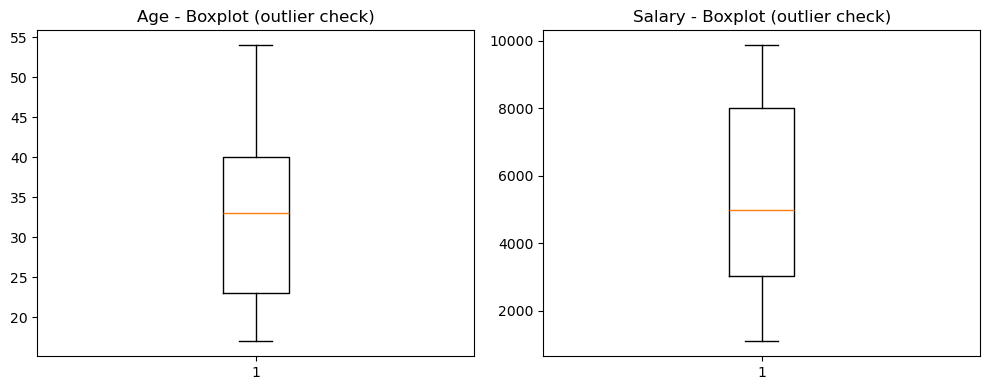

In [46]:
# 2e. Outlier detection using the IQR method (Age & Salary)
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)], lower, upper

age_outliers, age_low, age_high = find_outliers_iqr(df['Age'].dropna())
salary_outliers, sal_low, sal_high = find_outliers_iqr(df['Salary'].dropna())

print(f"Age outlier bounds: [{age_low:.1f}, {age_high:.1f}] -> {len(age_outliers)} outliers")
print(f"Salary outlier bounds: [{sal_low:.1f}, {sal_high:.1f}] -> {len(salary_outliers)} outliers")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['Age'].dropna())
axes[0].set_title('Age - Boxplot (outlier check)')
axes[1].boxplot(df['Salary'].dropna())
axes[1].set_title('Salary - Boxplot (outlier check)')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=110)
plt.show()

In [47]:
# 2f. Handle missing values in every column
# Numeric columns -> fill with median (robust to the outliers found above)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# Categorical columns -> fill with mode (most frequent value)
df['Company'] = df['Company'].fillna(df['Company'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 Company    0
Age        0
Salary     0
City       0
Country    0
Gender     0
dtype: int64


In [48]:
df.head()

,Company,Age,Salary,City,Country,Gender
0,TCS,20.0,5000.0,Chennai,India,0
1,Infosys,30.0,5000.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


## 3. Data Analysis

In [49]:
# 3a. Filter: Age > 40 and Salary < 5000
filtered_df = df[(df['Age'] > 40) & (df['Salary'] < 5000)]
print(f"Employees with Age > 40 and Salary < 5000: {len(filtered_df)}")
filtered_df

Employees with Age > 40 and Salary < 5000: 15


,Company,Age,Salary,City,Country,Gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
85,Infosys,41.0,3000.0,Delhi,India,0
92,Infosys,54.0,3184.0,Mumbai,India,0
103,Infosys,44.0,4034.0,Delhi,India,0


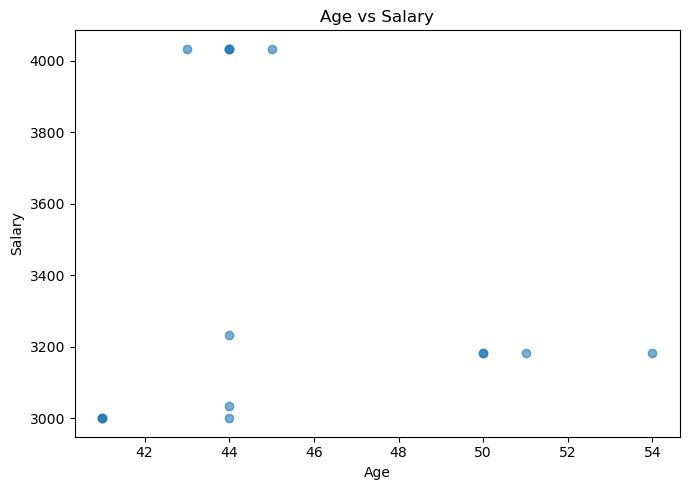

In [60]:
# 3b. Chart: Age vs Salary
plt.figure(figsize=(7, 5))
plt.scatter(filtered_df['Age'], filtered_df['Salary'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary')
plt.tight_layout()
plt.savefig('age_vs_salary.png', dpi=110)
plt.show()

City
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


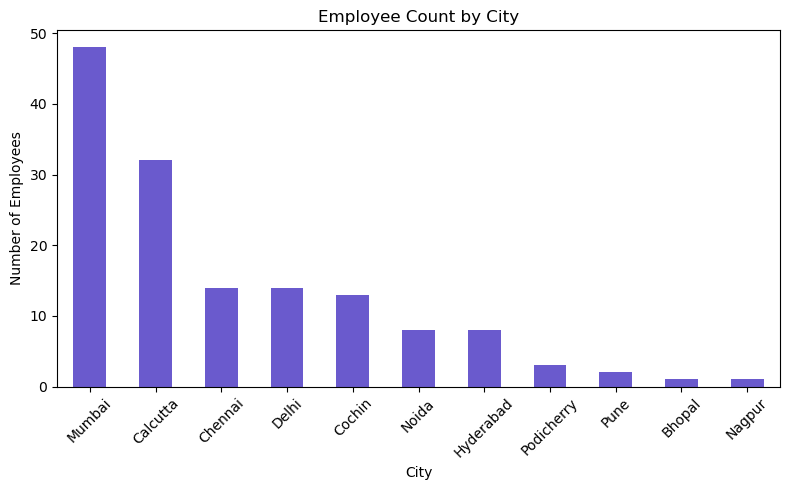

In [61]:
# 3c. Number of employees per City, shown visually
city_counts = df['City'].value_counts()
print(city_counts)

plt.figure(figsize=(8, 5))
city_counts.plot(kind='bar', color='slateblue')
plt.xlabel('City')
plt.ylabel('Number of Employees')
plt.title('Employee Count by City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('employees_by_city.png', dpi=110)
plt.show()

## 4. Data Encoding

In [62]:
# 4a. Label Encoding — used for the binary target column "Gender"
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print("Gender classes:", le.classes_)

Gender classes: [0 1]


In [63]:
# 4b. One-Hot Encoding — used for the nominal categorical columns
# (Company, City, Country) since they have no inherent order
df_encoded = pd.get_dummies(df, columns=['Company', 'City', 'Country'], drop_first=False)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes('bool').columns})
df_encoded.head()

,Age,Salary,Gender,Company_CTS,Company_Infosys,Company_TCS,City_Bhopal,City_Calcutta,City_Chennai,City_Cochin,City_Delhi,City_Hyderabad,City_Mumbai,City_Nagpur,City_Noida,City_Podicherry,City_Pune,Country_India
0,20.0,5000.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1
1,30.0,5000.0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
2,35.0,2300.0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1
3,40.0,3000.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,23.0,4000.0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1


In [64]:
print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (144, 18)


## 5. Feature Scaling

In [65]:
# Split first, then scale numeric columns only (fit on train, transform test)
X = df_encoded.drop(columns=['Gender'])
y = df_encoded['Gender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

numeric_cols = ['Age', 'Salary']

In [66]:
# 5a. StandardScaler (mean = 0, std = 1)
sc = StandardScaler()
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std[numeric_cols] = sc.fit_transform(X_train[numeric_cols])
X_test_std[numeric_cols] = sc.transform(X_test[numeric_cols])

print("StandardScaler result (train, first 5 rows):")
X_train_std[numeric_cols].head()

StandardScaler result (train, first 5 rows):


,Age,Salary
35,0.356931,1.528249
100,0.118285,-1.395298
111,-1.194267,-0.437512
40,-0.955621,-0.428729
17,0.237608,-0.154777


In [67]:
# 5b. MinMaxScaler (scales to [0, 1])
mm = MinMaxScaler()
X_train_mm = X_train.copy()
X_test_mm = X_test.copy()
X_train_mm[numeric_cols] = mm.fit_transform(X_train[numeric_cols])
X_test_mm[numeric_cols] = mm.transform(X_test[numeric_cols])

print("MinMaxScaler result (train, first 5 rows):")
X_train_mm[numeric_cols].head()

MinMaxScaler result (train, first 5 rows):


,Age,Salary
35,0.472222,0.903039
100,0.416667,0.107545
111,0.111111,0.368158
40,0.166667,0.370547
17,0.444444,0.445089


In [68]:
print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train shape: (115, 17)  X_test shape: (29, 17)
y_train distribution:
 Gender
0    87
1    28
Name: count, dtype: int64
y_test distribution:
 Gender
0    25
1     4
Name: count, dtype: int64


In [69]:
# Save the cleaned & standardized training set
cleaned_train = X_train_std.copy()
cleaned_train['Gender'] = y_train.values
cleaned_train.to_csv('Cleaned_Employee_Train.csv', index=False)
print("Saved Cleaned_Employee_Train.csv with shape:", cleaned_train.shape)

Saved Cleaned_Employee_Train.csv with shape: (115, 18)


## Summary

In this assignment, the raw Employee dataset was explored (unique values,
datatypes, and descriptive statistics for every column) and cleaned by
standardizing inconsistent company names, removing 4 duplicate rows,
treating invalid `Age == 0` entries as missing, detecting outliers in Age
and Salary with the IQR method, and imputing all remaining missing values
(median for numeric columns, mode for categorical columns). Employees
aged over 40 with a salary under 5000 were isolated, and the relationship
between Age/Salary and the distribution of employees across cities were
visualized. Categorical features were then encoded — Label Encoding for
the binary `Gender` target and One-Hot Encoding for the nominal `Company`,
`City`, and `Country` columns — before splitting the data 80/20 into
train/test sets. Finally, both StandardScaler and MinMaxScaler were
applied to the numeric `Age` and `Salary` features (fit on the training
set only, then applied to the test set) to complete the preprocessing
pipeline.